In [2]:
import os
import json
import gc

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint
from sklearn.metrics import mean_squared_error, r2_score

gc.collect()

0

### Functions

In [1]:
def evaluate_model(model, train_data, test_datasets, title, fit=True, figsize=(10, 10)):
    """
    Train and evaluate a regression model on multiple test datasets with scatter plots.
    
    Parameters
    ----------
    model : sklearn-like regressor
        The model to train and evaluate.
    train_data : tuple
        (X_train, y_train) data for fitting if fit=True.
    test_datasets : dict
        Dictionary of test datasets: {"name": (X_test, y_test), ...}.
    title : str
        Title for the entire figure.
    fit : bool, optional
        Whether to fit the model before evaluating (default: True).
    figsize : tuple, optional
        Figure size.
    """

    X_train, y_train = train_data
    if fit:
        model.fit(X_train, y_train)

    fig, axes = plt.subplots(2, 2, figsize=figsize, constrained_layout=True)
    axes = axes.flatten()

    for ax, (name, (X_test, y_test)) in zip(axes, test_datasets.items()):
        y_pred = model.predict(X_test)
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        pearson_corr = np.corrcoef(y_test, y_pred)[0, 1]

        ax.scatter(y_test, y_pred, alpha=0.6)
        ax.plot(y_test, y_test, color='red', linestyle='--')
        ax.set_title(f"{name.upper()}\nR²={r2:.3f}, RMSE={rmse:.3f}, PCC={pearson_corr:.3f}")
        ax.set_xlabel("True pK")
        ax.set_ylabel("Predicted pK")
        ax.grid(True, linestyle='--', alpha=0.5)

    fig.suptitle(title, fontsize=14, y=1.02)
    plt.show()

### **Train - Test - Split and Validation Split**

In [3]:
# Load full dataset
drop_cols = ["protein_sequences", "pocket_sequences", "ligand_smiles"]

df_all_encoded = pd.read_csv(
    r"C:\ZHAW\PA2\Sequence_based_models\PDBbind_protein_pocket_ligands_bindingsites_encoded.csv",)
df_all_encoded = df_all_encoded.drop(columns=drop_cols)
df_all_encoded = df_all_encoded.dropna().reset_index(drop=True)

# Load OOD splits
ood_splits_path = r"C:\ZHAW\PA2\Sequence_based_models\PDBbind_ood_splits"
split_files = [f for f in os.listdir(ood_splits_path) if f.endswith(".json")]

train_datasets, test_datasets, train_df_dict = {}, {}, {}

# Iterate over all JSON files in the directory
for file in split_files:
    split_name = file.split("_")[1]
    with open(os.path.join(ood_splits_path, file), "r") as f:
        split = json.load(f)

    # create train and test DataFrames
    train_df = df_all_encoded[df_all_encoded["pdb_id"].isin(split["train"])]
    test_ids = {pdb for k, v in split.items() if k != "train" for pdb in v}
    test_df = df_all_encoded[df_all_encoded["pdb_id"].isin(test_ids)]

    # keep full train_df with pdb_id for CV folds
    train_df_dict[split_name] = train_df.copy()

    # for model training
    X_train = train_df.drop(columns=["pK", "pdb_id"])
    y_train = train_df["pK"]

    X_test = test_df.drop(columns=["pK", "pdb_id"])
    y_test = test_df["pK"]

    train_datasets[split_name] = (X_train, y_train)
    test_datasets[split_name] = (X_test, y_test)

print(f"Loaded {len(train_datasets)} OOD splits:")
for name, (Xtr, _) in train_datasets.items():
    print(f" - {name}: {len(Xtr)} train / {len(test_datasets[name][0])} test samples")


Loaded 7 OOD splits:
 - 1nvq: 13373 train / 2636 test samples
 - 1sqa: 15172 train / 712 test samples
 - 2p15: 15378 train / 451 test samples
 - 2vw5: 15623 train / 206 test samples
 - 3dd0: 15404 train / 453 test samples
 - 3f3e: 15431 train / 390 test samples
 - 3o9i: 15494 train / 448 test samples


In [4]:
# Load validation splits from JSON files
val_splits_path = r"C:\ZHAW\PA2\Sequence_based_models\val_splits_ood"
val_split_files = [f for f in os.listdir(val_splits_path) if f.endswith(".json")]

# Parse JSON validation folds
val_splits_dict = {}

for file in val_split_files:
    base = os.path.splitext(file)[0]
    parts = base.split("_")
    split_name = parts[1]      
    fold_name = parts[-1]       

    with open(os.path.join(val_splits_path, file), "r") as f:
        fold_data = json.load(f)

    if split_name not in val_splits_dict:
        val_splits_dict[split_name] = []

    val_splits_dict[split_name].append({
        "fold": fold_name,
        "train": fold_data["train"],
        "validation": fold_data["validation"]
    })


# Helper to convert val IDs to scikit-learn CV folds 
def build_cv_splits(train_df, all_val_ids_list, id_col="pdb_id"):
    """
    Converts lists of validation IDs into scikit-learn-compatible
    index tuples (train_idx, val_idx) for RandomizedSearchCV.
    """
    cv_splits = []
    id_to_idx = {pid: idx for idx, pid in enumerate(train_df[id_col])}

    for val_ids in all_val_ids_list:
        val_idx = [id_to_idx[pid] for pid in val_ids if pid in id_to_idx]
        train_idx = [idx for pid, idx in id_to_idx.items() if pid not in val_ids]
        cv_splits.append((train_idx, val_idx))

    return cv_splits


# Build CV folds for each OOD split
cv_folds = {}
for split_name, train_df in train_df_dict.items():
    if split_name in val_splits_dict:
        val_ids_list = [fold["validation"] for fold in val_splits_dict[split_name]]
        cv_folds[split_name] = build_cv_splits(train_df, val_ids_list)
    else:
        print(f"Warning: No validation splits found for {split_name}")

---

### **Model selection & training**

#### **Regression**

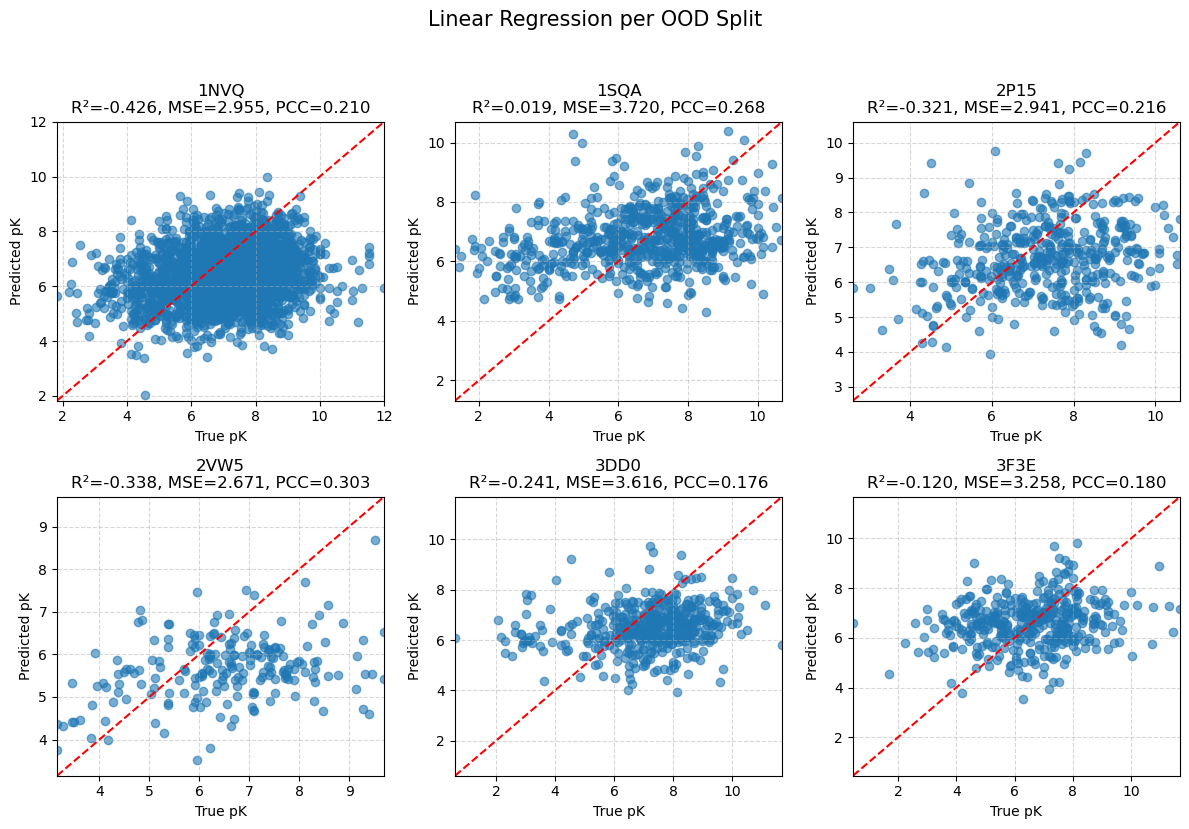

In [5]:
# Train and evaluate Linear Regression for each split
results = {}
models = {}

for name, (X_train, y_train) in train_datasets.items():
    X_test, y_test = test_datasets[name]

    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    pcc = np.corrcoef(y_test, y_pred)[0, 1]

    results[name] = {"R²": r2, "MSE": mse, "PCC": pcc}
    models[name] = model

# Plot
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for ax, (name, (X_test, y_test)) in zip(axes, test_datasets.items()):
    model = models[name]
    y_pred = model.predict(X_test)
    r2, mse, pcc = results[name]["R²"], results[name]["MSE"], results[name]["PCC"]

    ax.scatter(y_test, y_pred, alpha=0.6)
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, "r--")
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_title(f"{name.upper()}\nR²={r2:.3f}, MSE={mse:.3f}, PCC={pcc:.3f}")
    ax.set_xlabel("True pK")
    ax.set_ylabel("Predicted pK")
    ax.grid(True, linestyle="--", alpha=0.5)

plt.suptitle("Linear Regression per OOD Split", fontsize=15, y=1.03)
plt.tight_layout()
plt.show()

#### **HistGradientBoosting Regression**

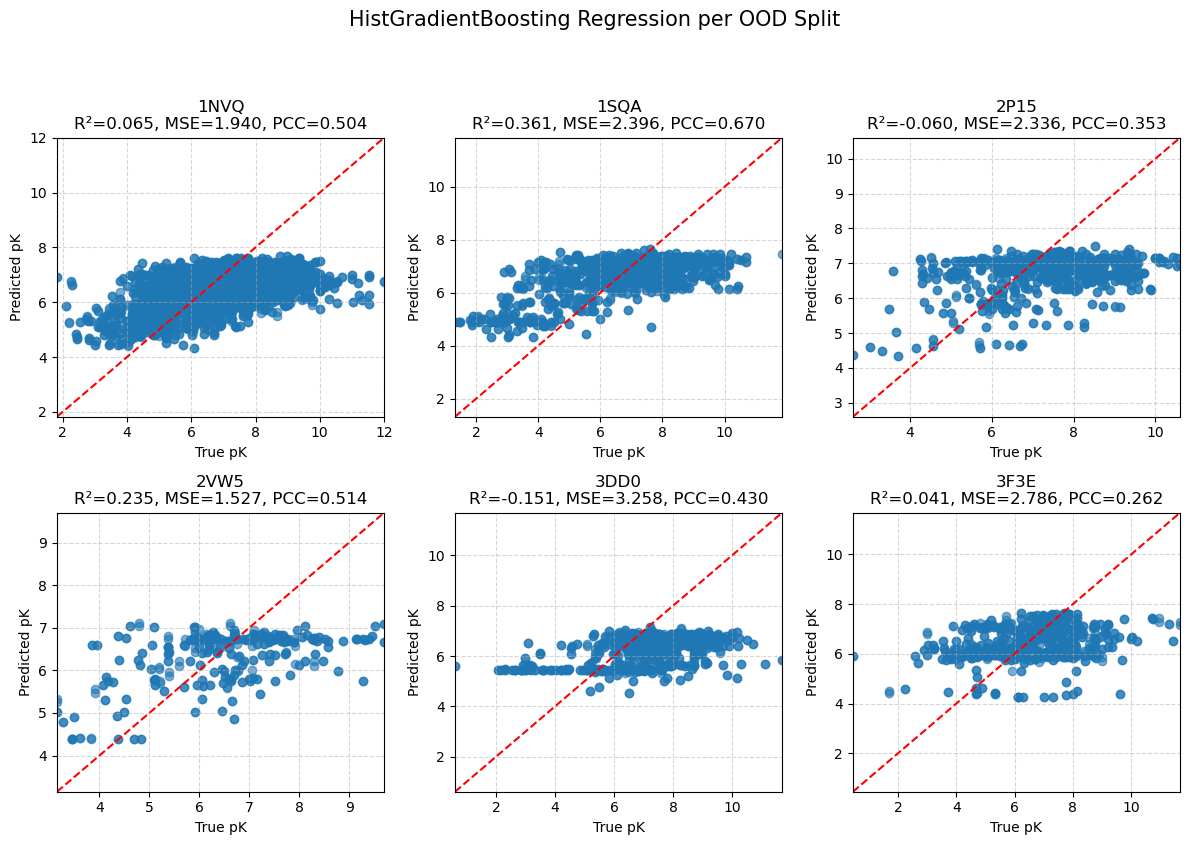

In [12]:
# Train and evaluate HistGradientBoosting for each split
results_hgb = {}
models_hgb = {}

for name, (X_train, y_train) in train_datasets.items():
    X_test, y_test = test_datasets[name]

    model = HistGradientBoostingRegressor(
    learning_rate=0.01,
    max_iter=300,
    max_depth=6,
    early_stopping=True,
    random_state=42
)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    pearson_corr = np.corrcoef(y_test, y_pred)[0, 1]

    results_hgb[name] = {"R²": r2, "MSE": mse, "PCC": pearson_corr}
    models_hgb[name] = (model, y_test, y_pred)

# Plot
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for ax, (name, (model, y_test, y_pred)) in zip(axes, models_hgb.items()):
    r2 = results_hgb[name]["R²"]
    mse = results_hgb[name]["MSE"]
    pcc = results_hgb[name]["PCC"]

    ax.scatter(y_test, y_pred, alpha=0.6)
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, "r--")
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_title(f"{name.upper()}\nR²={r2:.3f}, MSE={mse:.3f}, PCC={pcc:.3f}")
    ax.set_xlabel("True pK")
    ax.set_ylabel("Predicted pK")
    ax.grid(True, linestyle="--", alpha=0.5)

plt.suptitle("HistGradientBoosting Regression per OOD Split", fontsize=15, y=1.05)
plt.tight_layout()
plt.show()

#### **Randomized Search for HistGradientBoosting Regression**


🔹 Training 1NVQ split...
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best Params for 1NVQ: {'l2_regularization': np.float64(0.0007787658410143283), 'learning_rate': np.float64(0.054610577964560876), 'max_bins': 157, 'max_depth': 8, 'max_iter': 352, 'min_samples_leaf': 58}
1NVQ — CV R²=0.495, Test R²=0.048


🔹 Training 1SQA split...
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best Params for 1SQA: {'l2_regularization': np.float64(0.0007787658410143283), 'learning_rate': np.float64(0.054610577964560876), 'max_bins': 157, 'max_depth': 8, 'max_iter': 352, 'min_samples_leaf': 58}
1SQA — CV R²=0.506, Test R²=0.295


🔹 Training 2P15 split...
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best Params for 2P15: {'l2_regularization': np.float64(0.0007787658410143283), 'learning_rate': np.float64(0.054610577964560876), 'max_bins': 157, 'max_depth': 8, 'max_iter': 352, 'min_samples_leaf': 58}
2P15 — CV R²=0.510, Test R²=-0.118


🔹 Training 2VW5 split..

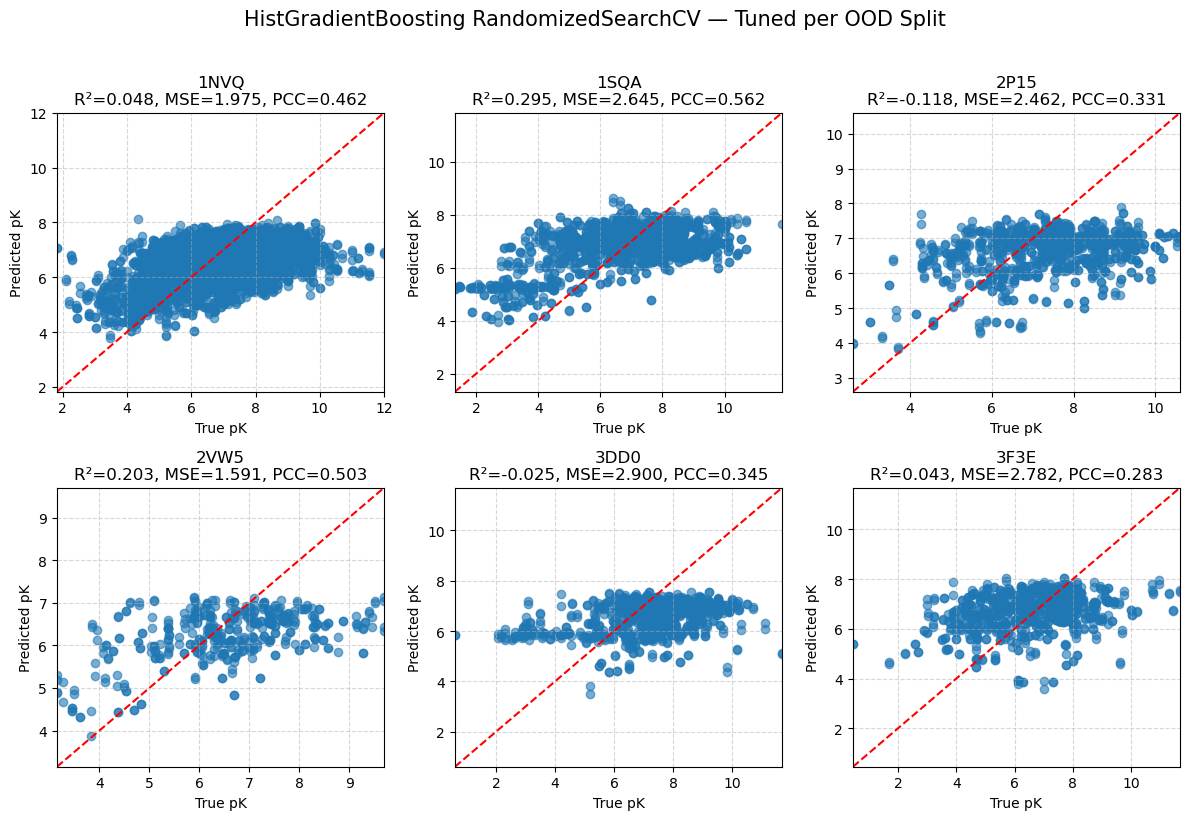

In [ ]:
# Parameter grid
param_dist = {
    "learning_rate": uniform(0.005, 0.05),
    "max_iter": randint(100, 600),
    "max_depth": randint(3, 10),
    "min_samples_leaf": randint(10, 80),
    "l2_regularization": uniform(0.0, 1.0),
    "max_bins": randint(100, 255)
}

best_models = {}
results_hgb_tuned = {}

for name, (X_train, y_train) in train_datasets.items():
    print(f"\n🔹 Training {name.upper()} split...")

    # Base model
    base_model = HistGradientBoostingRegressor(random_state=42)

    random_search = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=param_dist,
        n_iter=20,
        scoring="r2",
        verbose=2,
        n_jobs=-1,
        random_state=42,
        cv=cv_folds[name]
    )

    # Tune model with CV
    random_search.fit(X_train, y_train)

    best_params = random_search.best_params_
    print(f"Best Params for {name.upper()}: {best_params}")

    # Train best model on full training set
    best_model = HistGradientBoostingRegressor(
        **best_params,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1
    )

    best_model.fit(X_train, y_train)
    best_models[name] = best_model

    # --- Evaluate on test set ---
    X_test, y_test = test_datasets[name]
    y_pred = best_model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    pcc = np.corrcoef(y_test, y_pred)[0, 1]

    results_hgb_tuned[name] = {
        "BestParams": best_params,
        "CV_R²": random_search.best_score_,
        "Test_R²": r2,
        "Test_MSE": mse,
        "Test_PCC": pcc
    }

    print(f"{name.upper()} — CV R²={random_search.best_score_:.3f}, Test R²={r2:.3f}\n")

# --- Plot ---
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for ax, (name, model) in zip(axes, best_models.items()):
    X_test, y_test = test_datasets[name]
    y_pred = model.predict(X_test)
    res = results_hgb_tuned[name]

    ax.scatter(y_test, y_pred, alpha=0.6)
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, "r--")
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_title(f"{name.upper()}\nR²={res['Test_R²']:.3f}, MSE={res['Test_MSE']:.3f}, PCC={res['Test_PCC']:.3f}")
    ax.set_xlabel("True pK")
    ax.set_ylabel("Predicted pK")
    ax.grid(True, linestyle="--", alpha=0.5)

plt.suptitle("HistGradientBoosting RandomizedSearchCV — Tuned per OOD Split", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

#### **XGBoost**

c:\Users\ravid\.conda\envs\pa2\lib\site-packages\xgboost\core.py:158: UserWarning: [09:38:55] WARNING: D:\bld\xgboost-split_1744329000128\work\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


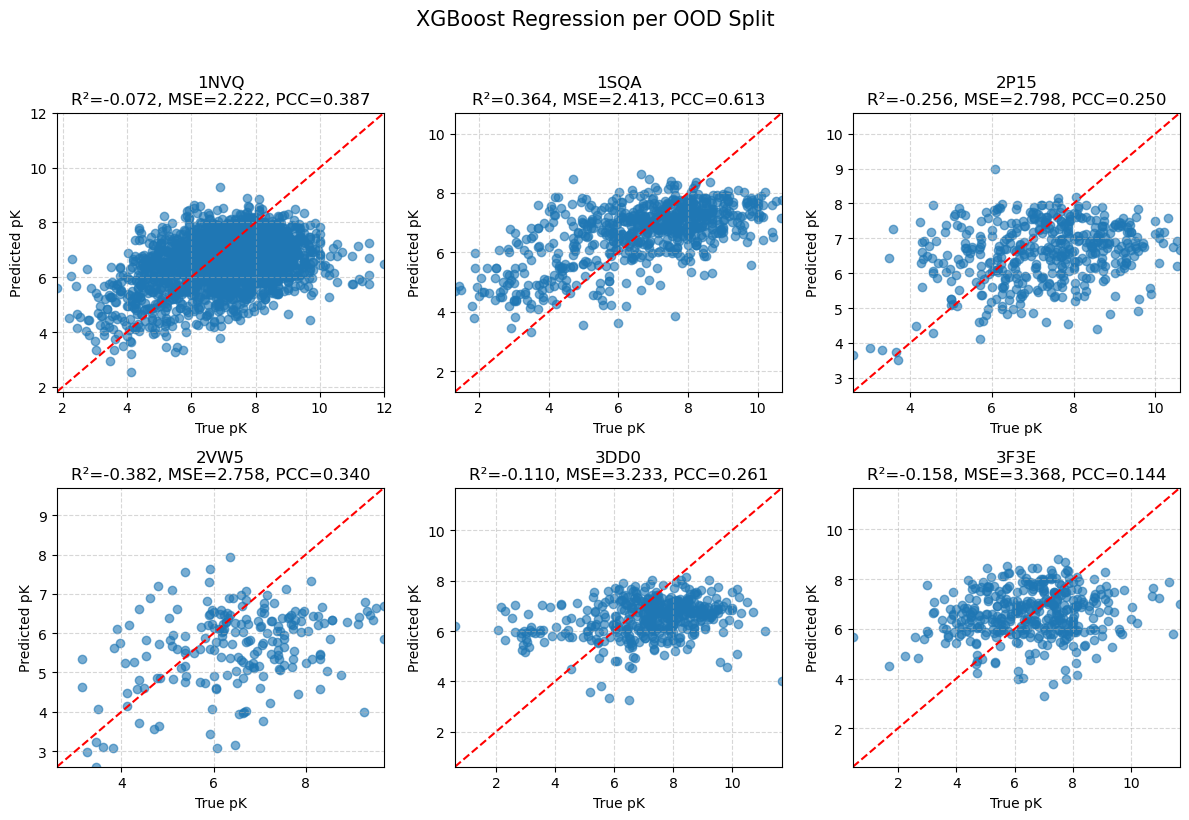

In [6]:
results_xgb = {}
models_xgb = {}

# Train and evaluate XGBRegressor per dataset
for name, (X_train, y_train) in train_datasets.items():
    X_test, y_test = test_datasets[name]

    model = XGBRegressor(
    objective="reg:squarederror",
    eval_metric="rmse",
    tree_method="hist",
    device="cuda",  
    random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    pearson_corr = np.corrcoef(y_test, y_pred)[0, 1]

    results_xgb[name] = {"R²": r2, "MSE": mse, "PCC": pearson_corr}
    models_xgb[name] = model

# Plots
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for ax, (name, (X_test, y_test)) in zip(axes, test_datasets.items()):
    model = models_xgb[name]
    y_pred = model.predict(X_test)

    r2 = results_xgb[name]["R²"]
    mse = results_xgb[name]["MSE"]
    pcc = results_xgb[name]["PCC"]

    ax.scatter(y_test, y_pred, alpha=0.6)
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, "r--")
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_title(f"{name.upper()}\nR²={r2:.3f}, MSE={mse:.3f}, PCC={pcc:.3f}")
    ax.set_xlabel("True pK")
    ax.set_ylabel("Predicted pK")
    ax.grid(True, linestyle="--", alpha=0.5)

plt.suptitle("XGBoost Regression per OOD Split", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

#### **Randomized Search for XGBoost**


 Tuning 1NVQ split...
Fitting 5 folds for each of 5 candidates, totalling 25 fits
1NVQ — CV R²=0.530, Test R²=0.001
Best Params: {'subsample': 0.8, 'reg_lambda': 50, 'reg_alpha': 0.1, 'n_estimators': 600, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


 Tuning 1SQA split...
Fitting 5 folds for each of 5 candidates, totalling 25 fits
1SQA — CV R²=0.540, Test R²=0.320
Best Params: {'subsample': 0.8, 'reg_lambda': 50, 'reg_alpha': 0.1, 'n_estimators': 600, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


 Tuning 2P15 split...
Fitting 5 folds for each of 5 candidates, totalling 25 fits
2P15 — CV R²=0.539, Test R²=-0.083
Best Params: {'subsample': 0.8, 'reg_lambda': 50, 'reg_alpha': 0.1, 'n_estimators': 600, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


 Tuning 2VW5 split...
Fitting 5 folds for each of 5 candidates, totalling 25 fits
2VW5 — CV R²=0.543, Test R²=0.040
Best Params: {'subsample': 0.8, 'reg_lambda': 50, 'reg_alpha': 0.1, 'n_e

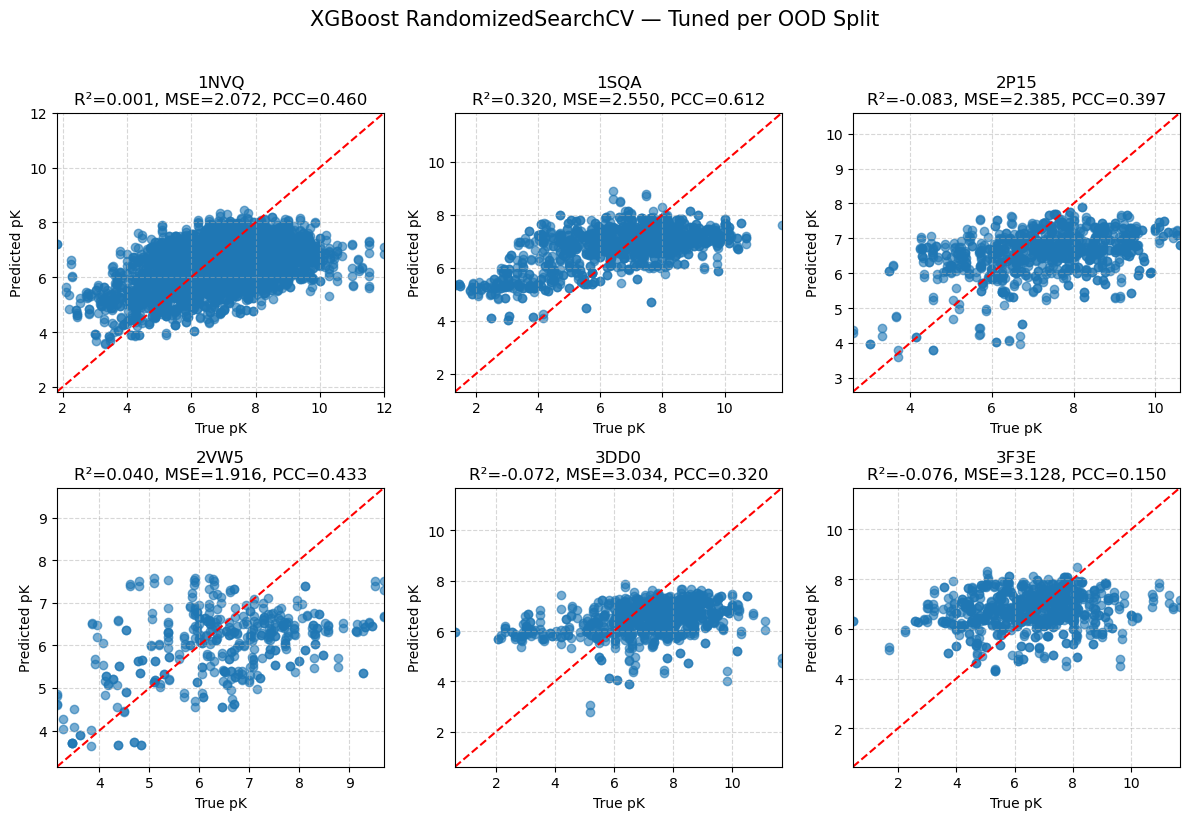

In [ ]:
# Base parameters
base_params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "tree_method": "hist",
    "device": "cuda",
    "random_state": 42
}

# Parameter space for tuning 
params = {
    'n_estimators': [200, 400, 600],
    'learning_rate': [0.005, 0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 0.01, 0.1, 1, 10],
    'reg_lambda': [0.1, 1, 10, 50]
}

results_xgb = {}

# Model tuning & evaluation per split
for name, (X_train, y_train) in train_datasets.items():
    X_test, y_test = test_datasets[name]
    print(f"\n Tuning {name.upper()} split...")

    model = XGBRegressor(**base_params)

    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=params,
        n_iter=20,
        scoring="r2",
        cv=cv_folds[name],  # pre-defined train/val indices
        verbose=2,
        random_state=42,
        n_jobs=-1
    )

    random_search.fit(X_train, y_train)
    best_params = random_search.best_params_

    # Evaluate best model
    X_test, y_test = test_datasets[name]
    best_model = XGBRegressor(**base_params, **best_params)
    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    pcc = np.corrcoef(y_test, y_pred)[0, 1]

    results_xgb[name] = {
        "R²": r2,
        "MSE": mse,
        "PCC": pcc,
        "best": best_model,
        "BestParams": best_params,
        "CV_R²": random_search.best_score_
    }

    print(f"{name.upper()} — CV R²={random_search.best_score_:.3f}, Test R²={r2:.3f}")
    print(f"Best Params: {best_params}\n")

# Plot
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for ax, (name, (X_test, y_test)) in zip(axes, test_datasets.items()):
    model = results_xgb[name]["best"]
    y_pred = model.predict(X_test)
    res = results_xgb[name]

    ax.scatter(y_test, y_pred, alpha=0.6)
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, "r--")
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_title(f"{name.upper()}\nR²={res['R²']:.3f}, MSE={res['MSE']:.3f}, PCC={res['PCC']:.3f}")
    ax.set_xlabel("True pK")
    ax.set_ylabel("Predicted pK")
    ax.grid(True, linestyle="--", alpha=0.5)

plt.suptitle("XGBoost RandomizedSearchCV — Tuned per OOD Split", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

| R² Value  | Meaning                                                                       |
| :-------- | :---------------------------------------------------------------------------- |
| **1.0**   | Perfect prediction        |
| **0.0**   | The model is no better than simply predicting the mean of the target variable |
| **< 0.0** | The model performs worse than predicting the mean                             |
